<a href="https://colab.research.google.com/github/DiegoSamanezDenis/COMP472-Brain-Tumor-MRI-CNN/blob/main/notebooks/4c_Classification_MRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
import os

files.upload()

!mkdir -p ~/.kaggle/
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d rm1000/brain-tumor-mri-scans

!unzip -q brain-tumor-mri-scans.zip -d dataset_mri_scans


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/rm1000/brain-tumor-mri-scans
License(s): CC0-1.0
 63% 149M/236M [00:00<00:00, 1.55GB/s]
100% 236M/236M [00:00<00:00, 963MB/s] 


In [5]:
# ── Verify dataset structure ──────────────────────────────────────────
# ImageFolder expects: dataset_4c/<class_name>/*.jpg
# If there's an extra nesting level, adjust DATA_ROOT accordingly.

import pathlib

DATA_ROOT = 'dataset_mri_scans'
top_level = sorted(os.listdir(DATA_ROOT))
print(f'Top-level contents of {DATA_ROOT}/ ({len(top_level)} items):')
for item in top_level[:10]:
    print(f'  {item}/')
if len(top_level) > 10:
    print(f'  ... and {len(top_level) - 10} more')

# If the zip has one wrapper folder, descend into it automatically
if len(top_level) == 1 and os.path.isdir(os.path.join(DATA_ROOT, top_level[0])):
    DATA_ROOT = os.path.join(DATA_ROOT, top_level[0])
    print(f'\n⚠️  Single subfolder detected — using DATA_ROOT = "{DATA_ROOT}"')
    adjusted = sorted(os.listdir(DATA_ROOT))
    print(f'Adjusted contents ({len(adjusted)} items):')
    for item in adjusted[:10]:
        print(f'  {item}/')
    if len(adjusted) > 10:
        print(f'  ... and {len(adjusted) - 10} more')

Top-level contents of dataset_mri_scans/ (4 items):
  glioma/
  healthy/
  meningioma/
  pituitary/


In [6]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/brain_tumor_weights'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Weights will be saved to: {SAVE_DIR}')

Mounted at /content/drive
Weights will be saved to: /content/drive/MyDrive/brain_tumor_weights


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import time
import json
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Dataset Splitting
We load the dataset twice (one per transform set) so that `Subset`
inherits the correct transforms for train vs. val/test.

In [9]:
def get_stratified_split_indices(targets, val_split=0.15, test_split=0.15):
  train_idx, temp_idx = train_test_split(
      np.arange(len(targets)),
      test_size=(val_split + test_split),
      stratify=targets,
      random_state=42
  )
  temp_targets = [targets[i] for i in temp_idx]
  val_idx, test_idx = train_test_split(
      temp_idx,
      test_size=test_split / (val_split + test_split),
      stratify=temp_targets,
      random_state=42
  )
  return train_idx, val_idx, test_idx

In [10]:
# Two ImageFolder instances — same images, different transforms
ds_train_aug = datasets.ImageFolder(DATA_ROOT, transform=train_transforms)
ds_eval      = datasets.ImageFolder(DATA_ROOT, transform=eval_transforms)

train_idx, val_idx, test_idx = get_stratified_split_indices(ds_eval.targets)

In [11]:
# Build subsets with correct transforms
train_set = Subset(ds_train_aug, train_idx)   # augmented
val_set   = Subset(ds_eval,      val_idx)     # clean
test_set  = Subset(ds_eval,      test_idx)    # clean

In [12]:
NUM_CLASSES = len(ds_eval.classes)
CLASS_NAMES = ds_eval.classes

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Total images : {len(ds_eval)}')
print(f'Train / Val / Test : {len(train_set)} / {len(val_set)} / {len(test_set)}')


Classes (4): ['glioma', 'healthy', 'meningioma', 'pituitary']
Total images : 7023
Train / Val / Test : 4916 / 1053 / 1054


In [13]:
NUM_WORKERS = 2  # safe default for Colab

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

dataloaders = {'train': train_loader, 'val': val_loader}

# Training & Evaluation Pipeline

In [14]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, device,
                num_epochs=25, save_path=None):
    """
    Train with validation, LR scheduling, history tracking, and best-weight saving.

    Args:
        scheduler: LR scheduler (stepped per epoch on val loss)
        dataloaders: dict with 'train' and 'val' keys
        save_path: .pth path to save best weights (also saves _history.json)
    Returns:
        model (best weights loaded), history dict
    """
    model = model.to(device)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [],   'val_acc': [],
        'lr': []
    }

    since = time.time()

    for epoch in range(num_epochs):
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        print(f'Epoch {epoch + 1}/{num_epochs}  (lr={current_lr:.2e})')
        print('-' * 45)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase], desc=f'  {phase}', leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc  = (running_corrects.double() / len(dataloaders[phase].dataset)).item()

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f'  {phase:5s}  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

            if phase == 'val':
                # Step the scheduler on validation loss
                scheduler.step(epoch_loss)

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    if save_path:
                        torch.save(best_model_wts, save_path)
                        print(f'  ✓ New best model saved ({save_path})')
        print()

    elapsed = time.time() - since
    print(f'Training complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)

    if save_path:
        history_path = save_path.replace('.pth', '_history.json')
        with open(history_path, 'w') as f:
            json.dump(history, f)
        print(f'History saved to {history_path}')

    return model, history

In [15]:
def evaluate_model(model, test_loader, class_names, device):
    """Run evaluation on test set. Returns confusion matrix, labels, preds."""
    model = model.to(device).eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Evaluating', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds,
                                target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    return cm, all_labels, all_preds

In [16]:
def plot_training_curves(history, title=''):
    """Plot loss, accuracy, and learning rate curves."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-', label='Validation')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train')
    axes[1].plot(epochs, history['val_acc'],   'r-', label='Validation')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if 'lr' in history:
        axes[2].plot(epochs[:len(history['lr'])], history['lr'], 'g-')
        axes[2].set_title(f'{title} — Learning Rate')
        axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
        axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)
    else:
        axes[2].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, class_names, title=''):
    """Plot confusion matrix as a heatmap."""
    fig, ax = plt.subplots(figsize=(max(8, len(class_names) * 0.5),
                                     max(6, len(class_names) * 0.4)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{title} — Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Helper: Build model + optimizer + scheduler

In [17]:
def build_experiment(model, lr=1e-3):
    """Return criterion, optimizer, and scheduler for a model."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    return criterion, optimizer, scheduler

## Model Definitions
Set `USE_PRETRAINED = True` (recommended) for transfer learning,
or `False` to train from scratch as in the original notebook.

In [18]:
USE_PRETRAINED = False  # ← flip to True for much better results

def _weights(flag):
    """Return pretrained weights arg or None."""
    return 'IMAGENET1K_V1' if flag else None

# ── ResNet18 ──────────────────────────────────────────────────────────
model_resnet = models.resnet18(weights=_weights(USE_PRETRAINED))
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, NUM_CLASSES)
criterion_resnet, optimizer_resnet, scheduler_resnet = build_experiment(model_resnet)
print(f'ResNet18    params: {sum(p.numel() for p in model_resnet.parameters() if p.requires_grad):,}')

# ── MobileNetV2 ──────────────────────────────────────────────────────
model_mobilenet = models.mobilenet_v2(weights=_weights(USE_PRETRAINED))
model_mobilenet.classifier[1] = nn.Linear(model_mobilenet.last_channel, NUM_CLASSES)
criterion_mobile, optimizer_mobile, scheduler_mobile = build_experiment(model_mobilenet)
print(f'MobileNetV2 params: {sum(p.numel() for p in model_mobilenet.parameters() if p.requires_grad):,}')

# ── VGG16 ─────────────────────────────────────────────────────────────
model_vgg = models.vgg16(weights=_weights(USE_PRETRAINED))
model_vgg.classifier[6] = nn.Linear(4096, NUM_CLASSES)
criterion_vgg, optimizer_vgg, scheduler_vgg = build_experiment(model_vgg)
print(f'VGG16       params: {sum(p.numel() for p in model_vgg.parameters() if p.requires_grad):,}')


ResNet18    params: 11,178,564
MobileNetV2 params: 2,228,996
VGG16       params: 134,276,932


# Train ResNet18 (Scratch) — 4c

In [19]:
model_resnet, history_resnet = train_model(
    model_resnet, criterion_resnet, optimizer_resnet, scheduler_resnet,
    dataloaders, device,
    num_epochs=20,
    save_path=os.path.join(SAVE_DIR, 'resnet18_4c.pth')
)

Epoch 1/20  (lr=1.00e-03)
---------------------------------------------


  train:   0%|          | 0/154 [00:00<?, ?it/s]

  train  Loss: 0.8495  Acc: 0.6564


  val:   0%|          | 0/33 [00:00<?, ?it/s]

  val    Loss: 0.8182  Acc: 0.6505
  ✓ New best model saved (/content/drive/MyDrive/brain_tumor_weights/resnet18_4c.pth)

Epoch 2/20  (lr=1.00e-03)
---------------------------------------------


...

  val    Loss: 0.1104  Acc: 0.9592

Epoch 20/20  (lr=1.00e-03)
---------------------------------------------


  train:   0%|          | 0/154 [00:00<?, ?it/s]

  train  Loss: 0.0939  Acc: 0.9664


  val:   0%|          | 0/33 [00:00<?, ?it/s]

  val    Loss: 0.1234  Acc: 0.9516

Training complete in 13m 19s
Best val Acc: 0.9706
History saved to /content/drive/MyDrive/brain_tumor_weights/resnet18_4c_history.json


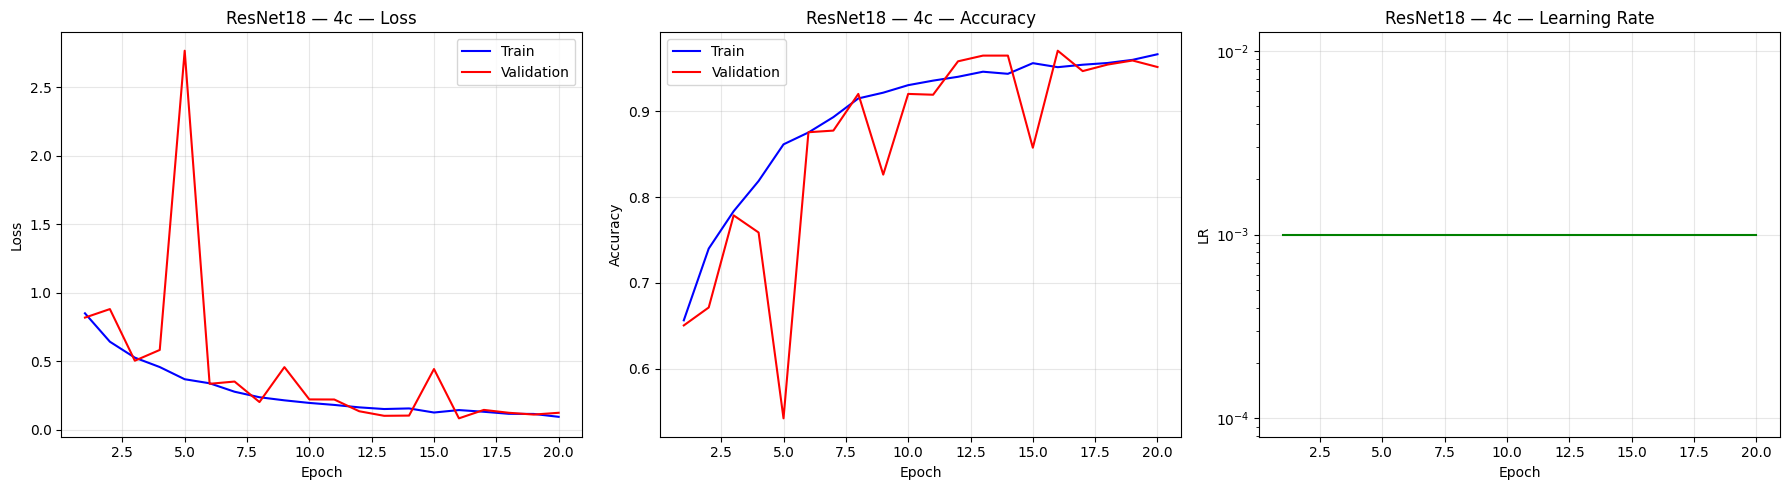

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.97      0.95       243
     healthy       0.97      0.97      0.97       300
  meningioma       0.95      0.90      0.92       247
   pituitary       0.97      0.98      0.98       264

    accuracy                           0.96      1054
   macro avg       0.96      0.96      0.95      1054
weighted avg       0.96      0.96      0.96      1054



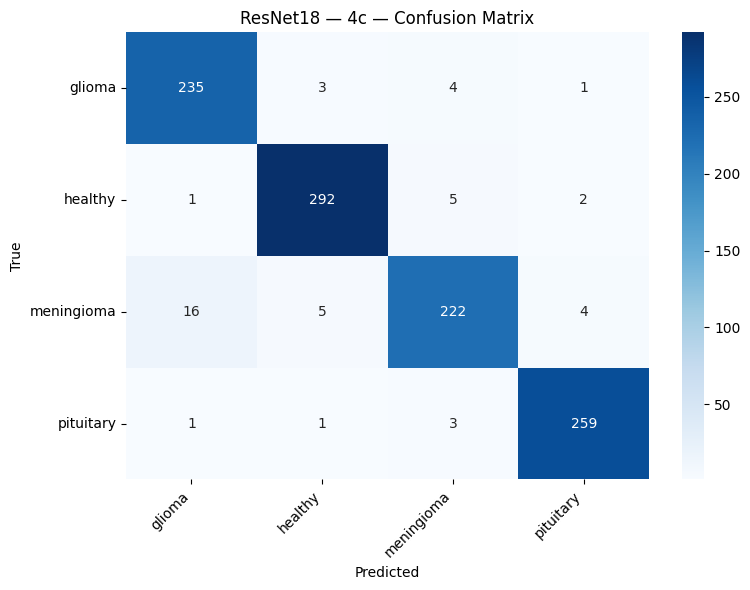

In [20]:
plot_training_curves(history_resnet, title='ResNet18 — 4c')
cm_resnet, _, _ = evaluate_model(model_resnet, test_loader, CLASS_NAMES, device)
plot_confusion_matrix(cm_resnet, CLASS_NAMES, title='ResNet18 — 4c')

# Train MobileNetV2 (Scratch) — 4c

In [21]:
model_mobilenet, history_mobilenet = train_model(
    model_mobilenet, criterion_mobile, optimizer_mobile, scheduler_mobile,
    dataloaders, device,
    num_epochs=20,
    save_path=os.path.join(SAVE_DIR, 'mobilenetv2_4c.pth')
)

Epoch 1/20  (lr=1.00e-03)
---------------------------------------------


  train:   0%|          | 0/154 [00:00<?, ?it/s]

  train  Loss: 0.8916  Acc: 0.6239


  val:   0%|          | 0/33 [00:00<?, ?it/s]

  val    Loss: 0.5995  Acc: 0.7502
  ✓ New best model saved (/content/drive/MyDrive/brain_tumor_weights/mobilenetv2_4c.pth)

Epoch 2/20  (lr=1.00e-03)
---------------------------------------------


...

  val    Loss: 0.0798  Acc: 0.9734

Epoch 20/20  (lr=5.00e-04)
---------------------------------------------


  train:   0%|          | 0/154 [00:00<?, ?it/s]

  train  Loss: 0.0673  Acc: 0.9748


  val:   0%|          | 0/33 [00:00<?, ?it/s]

  val    Loss: 0.0566  Acc: 0.9782
  ✓ New best model saved (/content/drive/MyDrive/brain_tumor_weights/mobilenetv2_4c.pth)

Training complete in 13m 25s
Best val Acc: 0.9782
History saved to /content/drive/MyDrive/brain_tumor_weights/mobilenetv2_4c_history.json


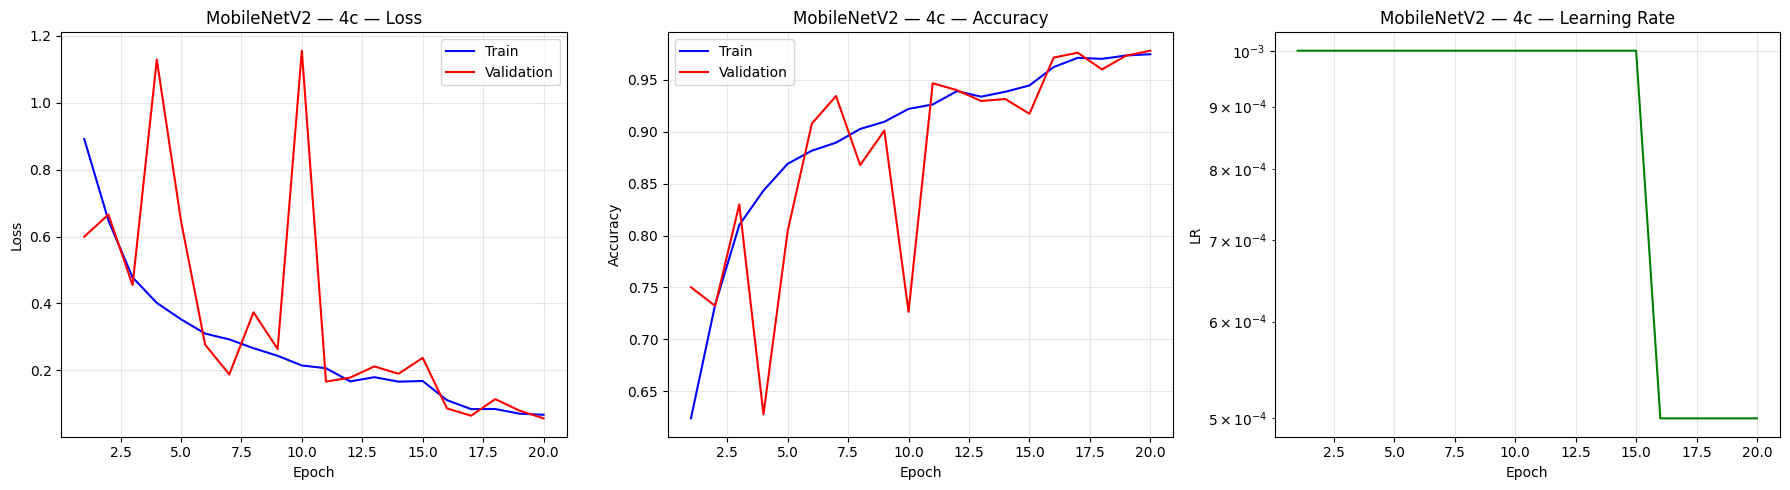

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.97      0.95       243
     healthy       1.00      0.99      0.99       300
  meningioma       0.96      0.95      0.96       247
   pituitary       0.99      0.98      0.99       264

    accuracy                           0.97      1054
   macro avg       0.97      0.97      0.97      1054
weighted avg       0.97      0.97      0.97      1054



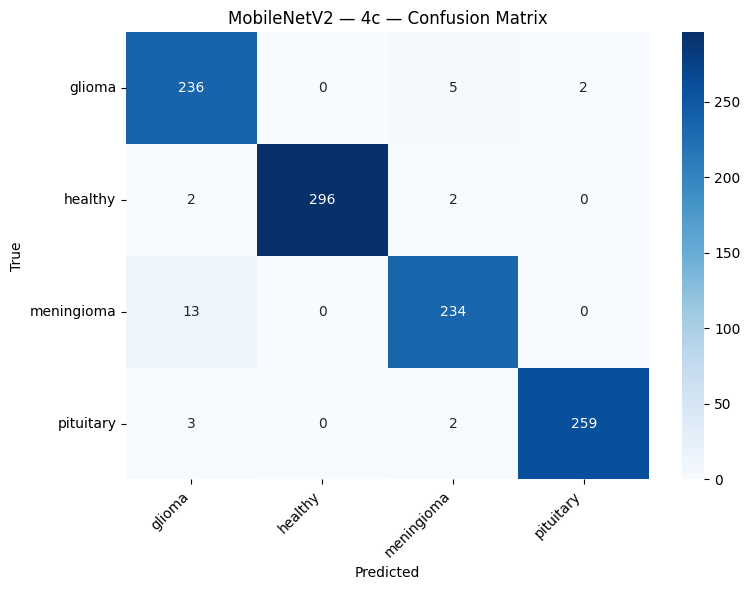

In [22]:
plot_training_curves(history_mobilenet, title='MobileNetV2 — 4c')
cm_mobile, _, _ = evaluate_model(model_mobilenet, test_loader, CLASS_NAMES, device)
plot_confusion_matrix(cm_mobile, CLASS_NAMES, title='MobileNetV2 — 4c')


# Train VGG16 (Scratch) — 4c

In [23]:
model_vgg, history_vgg = train_model(
    model_vgg, criterion_vgg, optimizer_vgg, scheduler_vgg,
    dataloaders, device,
    num_epochs=20,
    save_path=os.path.join(SAVE_DIR, 'vgg16_4c.pth')
)

Epoch 1/20  (lr=1.00e-03)
---------------------------------------------


  train:   0%|          | 0/154 [00:00<?, ?it/s]

  train  Loss: 2.8474  Acc: 0.2748


  val:   0%|          | 0/33 [00:00<?, ?it/s]

  val    Loss: 1.2799  Acc: 0.2849
  ✓ New best model saved (/content/drive/MyDrive/brain_tumor_weights/vgg16_4c.pth)

Epoch 2/20  (lr=1.00e-03)
---------------------------------------------


...

  val    Loss: 1.3827  Acc: 0.2849

Epoch 20/20  (lr=6.25e-05)
---------------------------------------------


  train:   0%|          | 0/154 [00:00<?, ?it/s]

  train  Loss: 1.3828  Acc: 0.2848


  val:   0%|          | 0/33 [00:00<?, ?it/s]

  val    Loss: 1.3827  Acc: 0.2849

Training complete in 26m 54s
Best val Acc: 0.2849
History saved to /content/drive/MyDrive/brain_tumor_weights/vgg16_4c_history.json


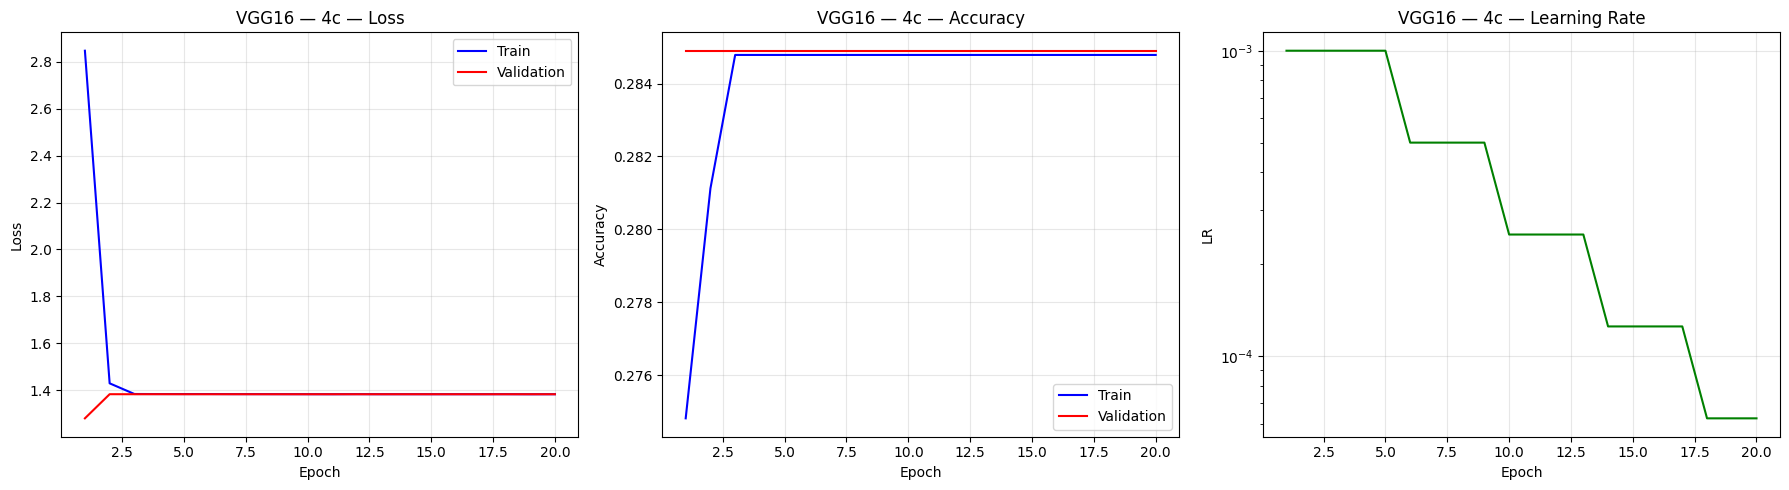

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       243
     healthy       0.28      1.00      0.44       300
  meningioma       0.00      0.00      0.00       247
   pituitary       0.00      0.00      0.00       264

    accuracy                           0.28      1054
   macro avg       0.07      0.25      0.11      1054
weighted avg       0.08      0.28      0.13      1054



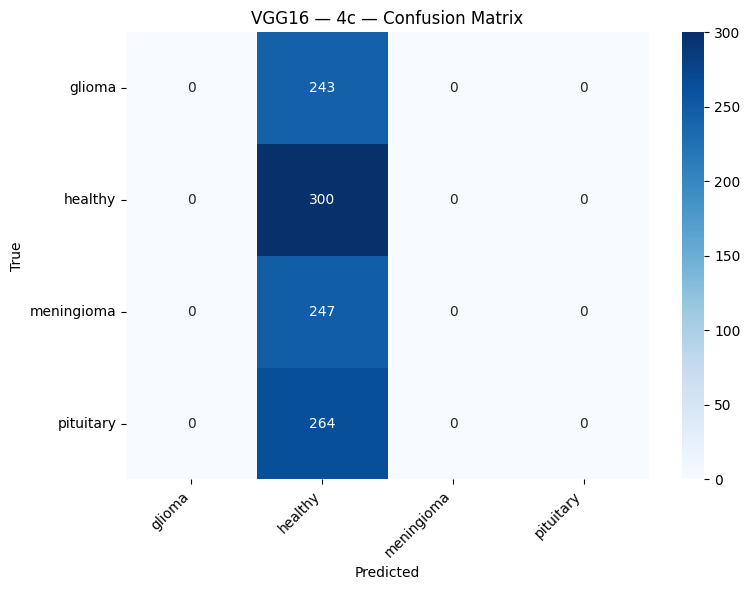

In [24]:
plot_training_curves(history_vgg, title='VGG16 — 4c')
cm_vgg, _, _ = evaluate_model(model_vgg, test_loader, CLASS_NAMES, device)
plot_confusion_matrix(cm_vgg, CLASS_NAMES, title='VGG16 — 4c')

# Reload Saved Model & History (Example)
Use this to reload weights after a runtime restart without retraining.

In [25]:
# model_reloaded = models.resnet18(weights=None)
# model_reloaded.fc = nn.Linear(model_reloaded.fc.in_features, NUM_CLASSES)
# model_reloaded.load_state_dict(
#     torch.load(os.path.join(SAVE_DIR, 'resnet18_4c.pth'), map_location=device)
# )
# model_reloaded.to(device).eval()
#
# with open(os.path.join(SAVE_DIR, 'resnet18_4c_history.json')) as f:
#     history_reloaded = json.load(f)
# plot_training_curves(history_reloaded, title='ResNet18 — 4c (reloaded)')